### FinTrust Week 3 — Advanced Python Analysis
Track: Data Analytics | Deliverable: Part C — Advanced Python Analysis

This notebook extends the Week 2 EDA with deeper analysis: trend validation, customer segmentation, comparative statistics, and two findings carried over from the Week 3 SQL analysis for cross-tool validation.

## Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

### 1. Load and prepare data (same as Week 2)

In [3]:
customers = pd.read_csv("FinTrust_Customer_Data - FinTrust_Customer_Data.csv")
transactions = pd.read_csv("FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv")

transactions['Transaction_DateTime'] = pd.to_datetime(
    transactions['Transaction_DateTime'], format='%m/%d/%Y %H:%M'
)
transactions['Device_Type'] = transactions['Device_Type'].fillna('Unknown')
transactions['Location'] = transactions['Location'].fillna('Unknown')
transactions['Is_Risk_Flagged'] = transactions['Risk_Review_Flag'] == 'Yes'

print("Customers:", customers.shape, "| Transactions:", transactions.shape)

Customers: (1500, 12) | Transactions: (12000, 12)


### 2. Validating the "February Dip" — Daily Trend Analysis
Why this is here: the Week 3 SQL analysis found monthly transaction counts of 4,133 / 3,734 / 4,133 for Jan/Feb/Mar — a -9.7% "dip" in February that looked like a real pattern. This section validates whether that's a genuine business signal or a calendar artifact (Feb has fewer days), using the same logic SQL can't easily express on its own.

Raw monthly counts:
Transaction_DateTime
1    4133
2    3734
3    4133
dtype: int64

Daily transaction RATE (count / days in month):
1    133.3
2    133.4
3    133.3
dtype: float64


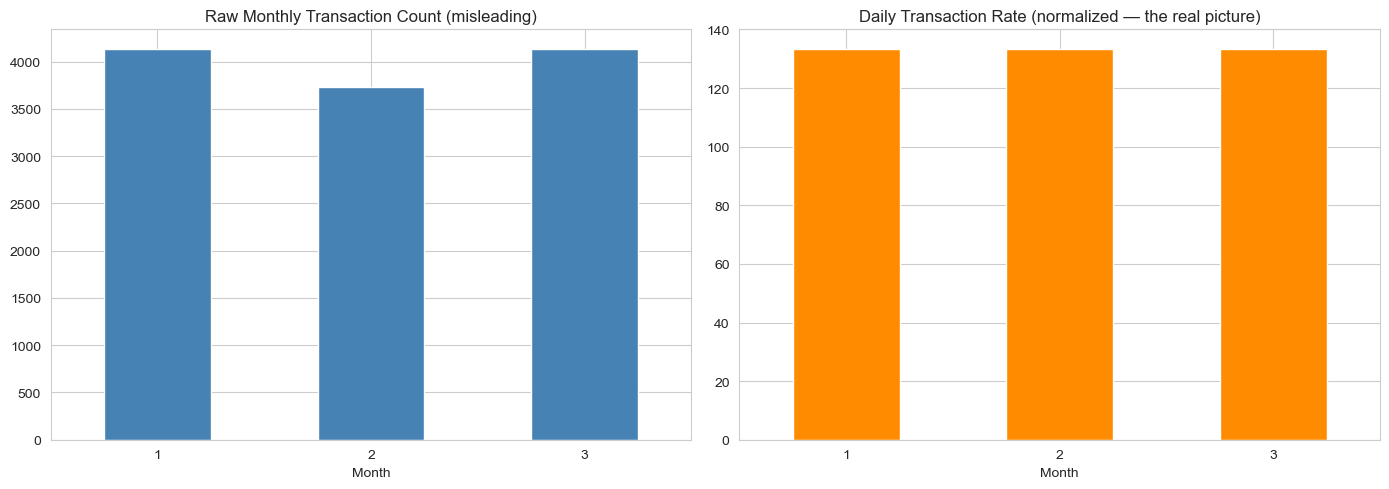

In [4]:
daily = transactions.groupby(transactions['Transaction_DateTime'].dt.date).size()
daily.index = pd.to_datetime(daily.index)

monthly_days = transactions['Transaction_DateTime'].dt.to_period('M').value_counts().sort_index()
days_in_month = transactions['Transaction_DateTime'].dt.to_period('M').dt.days_in_month if hasattr(transactions['Transaction_DateTime'].dt.to_period('M'), 'dt') else None

# Simpler: compute days in month directly
monthly_counts = transactions.groupby(transactions['Transaction_DateTime'].dt.month).size()
days_per_month = {1: 31, 2: 28, 3: 31}
daily_rate = pd.Series({m: monthly_counts[m] / days_per_month[m] for m in monthly_counts.index})

print("Raw monthly counts:")
print(monthly_counts)
print("\nDaily transaction RATE (count / days in month):")
print(daily_rate.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Raw Monthly Transaction Count (misleading)')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=0)

daily_rate.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Daily Transaction Rate (normalized — the real picture)')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Validation result: once normalized by days-in-month, the daily rate is ~133 transactions/day across all three months (flat line on the right chart) — confirming the SQL finding that February's apparent dip is a calendar artifact, not a real seasonal slowdown. This is a genuine Week 2 finding validated, not just repeated — the original Week 2 work never tested whether monthly comparisons needed day-count normalization.

### 3. Customer Segmentation by Digital Engagement Quartile
Why this is here: Week 2 found a near-zero correlation (r ≈ 0.04) between digital engagement score and transaction count, using a scatter plot. This section re-tests that finding with a different method — quartile segmentation plus a formal statistical test — which is a stronger form of validation than re-running the same correlation.

                         mean  median  count
Engagement_Quartile                         
Q1 (Lowest)          7.942559     8.0    383
Q2                   7.896739     8.0    368
Q3                   7.898396     7.0    374
Q4 (Highest)         8.261333     8.0    375


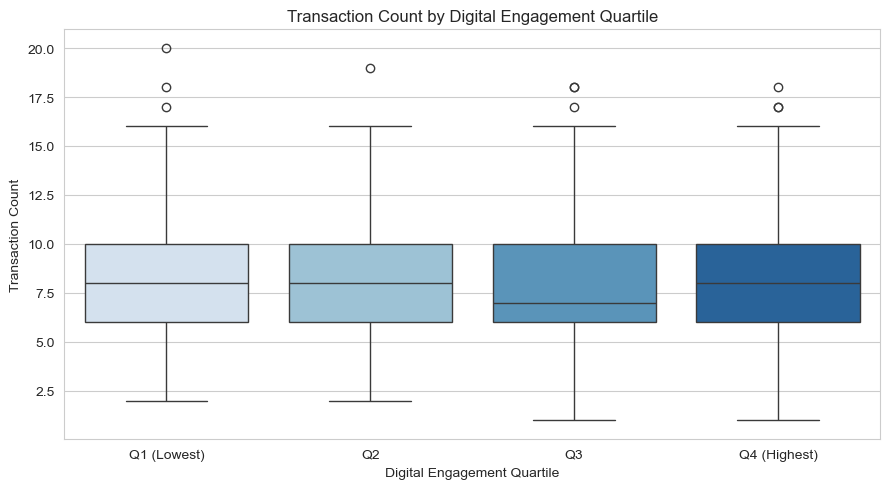


ANOVA test — F-statistic: 1.410, p-value: 0.238


In [6]:
customers['Engagement_Quartile'] = pd.qcut(
    customers['Digital_Engagement_Score'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

txn_count_per_customer = transactions.groupby('Customer_ID')['Transaction_ID'].count().rename('Transaction_Count')
customer_behaviour = customers.merge(txn_count_per_customer, on='Customer_ID', how='left')
customer_behaviour['Transaction_Count'] = customer_behaviour['Transaction_Count'].fillna(0)

print(customer_behaviour.groupby('Engagement_Quartile', observed=False)['Transaction_Count'].agg(['mean', 'median', 'count']))

plt.figure(figsize=(9, 5))
sns.boxplot(data=customer_behaviour, x='Engagement_Quartile', y='Transaction_Count',
            hue='Engagement_Quartile', palette='Blues', legend=False)
plt.title('Transaction Count by Digital Engagement Quartile')
plt.xlabel('Digital Engagement Quartile')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

# One-way ANOVA: is there a statistically significant difference between quartile groups?
groups = [g['Transaction_Count'].values for _, g in customer_behaviour.groupby('Engagement_Quartile', observed=False)]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA test — F-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")

### 4. High-Value Transaction Analysis (Per-Type 90th Percentile)
Why this is here: this mirrors SQL Q4 from the Week 3 advanced analysis, identifying transactions that are unusually large for their own type — a deeper version of the Week 2 outlier analysis that used a fixed IQR multiplier instead of a percentile-based threshold.

High-value transaction count by type:
Transaction_Type
Transfer           355
Card Purchase      304
Bill Payment       148
Cash Withdrawal    143
Deposit            133
Airtime/Data       119
Name: count, dtype: int64

Risk-review rate: high-value vs. normal transactions (%):
Is_High_Value
False    18.5
True     29.5
Name: Is_Risk_Flagged, dtype: float64


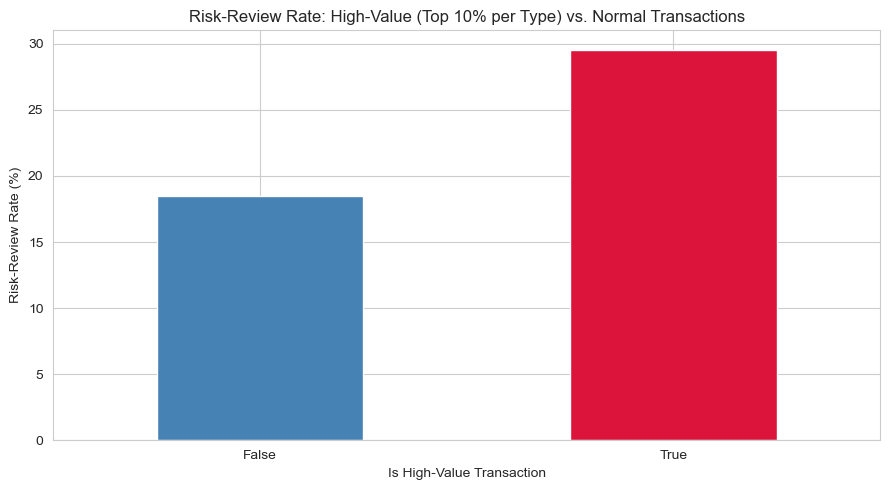

In [7]:
p90_by_type = transactions.groupby('Transaction_Type')['Amount_NGN'].quantile(0.9)
transactions['Is_High_Value'] = transactions.apply(
    lambda row: row['Amount_NGN'] > p90_by_type[row['Transaction_Type']], axis=1
)

high_value_counts = transactions[transactions['Is_High_Value']]['Transaction_Type'].value_counts()
high_value_risk_rate = transactions.groupby('Is_High_Value')['Is_Risk_Flagged'].mean() * 100

print("High-value transaction count by type:")
print(high_value_counts)
print("\nRisk-review rate: high-value vs. normal transactions (%):")
print(high_value_risk_rate.round(1))

plt.figure(figsize=(9, 5))
high_value_risk_rate.plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Risk-Review Rate: High-Value (Top 10% per Type) vs. Normal Transactions')
plt.xlabel('Is High-Value Transaction')
plt.ylabel('Risk-Review Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Segment × Channel Success Rate (Deeper Than Week 2's Single-Variable View)
Why this is here: Week 2 only looked at success rate by channel alone. This checks whether success rate actually depends on the combination of segment and channel — the same kind of deeper, combination-level analysis that proved important for the risk-review heatmap in Week 2.

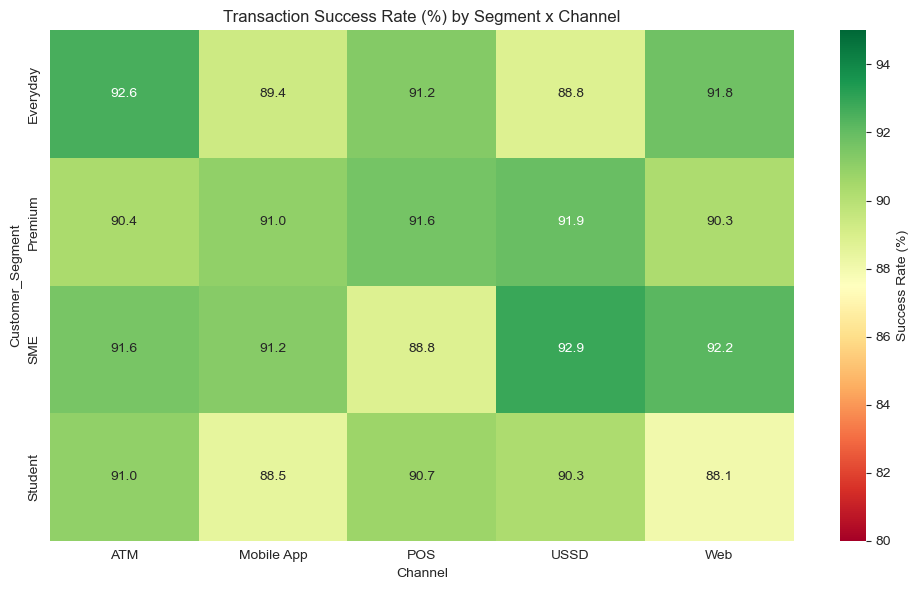

In [8]:
success_pivot = transactions.merge(
    customers[['Customer_ID', 'Customer_Segment']], on='Customer_ID', how='left'
).pivot_table(
    index='Customer_Segment', columns='Channel', values='Transaction_Status',
    aggfunc=lambda s: (s == 'Successful').mean() * 100
)

plt.figure(figsize=(10, 6))
sns.heatmap(success_pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=80, vmax=95,
            cbar_kws={'label': 'Success Rate (%)'})
plt.title('Transaction Success Rate (%) by Segment x Channel')
plt.tight_layout()
plt.show()

### 6. Weekday Transaction Pattern
Why this is here: a new trend dimension not explored in Week 2 — whether transaction behavior differs by day of the week, which matters for staffing and system-load planning.

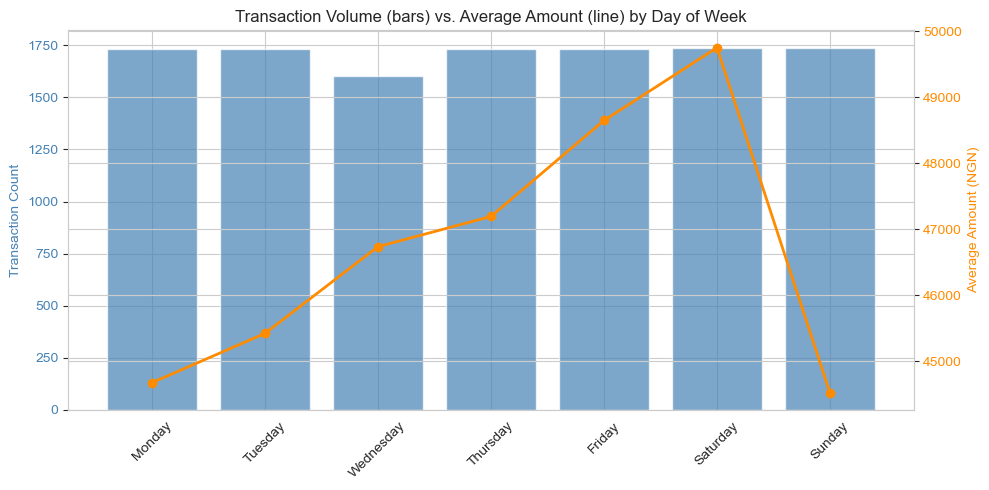

In [9]:
transactions['Day_Name'] = transactions['Transaction_DateTime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_counts = transactions['Day_Name'].value_counts().reindex(day_order)
weekday_avg_amount = transactions.groupby('Day_Name')['Amount_NGN'].mean().reindex(day_order)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(weekday_counts.index, weekday_counts.values, color='steelblue', alpha=0.7)
ax1.set_ylabel('Transaction Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(weekday_avg_amount.index, weekday_avg_amount.values, color='darkorange', marker='o', linewidth=2)
ax2.set_ylabel('Average Amount (NGN)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Transaction Volume (bars) vs. Average Amount (line) by Day of Week')
fig.tight_layout()
plt.show()


### Summary of Observations

1. February "Dip" — Validated as a Calendar Artifact

Finding: Raw monthly transaction counts suggested a real February slowdown (4,133 → 3,734 → 4,133, a -9.7% drop).
Evidence: Normalizing by days-in-month gives a daily rate of 133.3 / 133.4 / 133.3 transactions/day — essentially flat across all three months.
Validation: The original SQL finding (and the raw monthly view) is not supported once normalized — there is no real demand dip in February.
Business Meaning: Any staffing or capacity decision based on the raw monthly totals would be responding to a false signal; comparisons across months with different day-counts must always be normalized first.

2. Digital Engagement vs. Transaction Activity — Validated as No Relationship

Finding: Week 2's scatter plot suggested near-zero correlation (r ≈ 0.04) between engagement score and transaction count.
Evidence: Quartile means are nearly identical (7.94, 7.90, 7.90, 8.26), and a one-way ANOVA across the four quartiles gives F = 1.410, p = 0.238 — not statistically significant at the standard 0.05 threshold.
Validation: The Week 2 finding holds up under a formal statistical test, not just a visual impression.
Business Meaning: Digital engagement campaigns should not be expected to move transaction volume — confirmed with enough statistical rigor to act on, not just a suggestive chart.

3. High-Value Transactions Carry Real Risk Signal

Finding: Transactions in the top 10% of value for their own type are meaningfully riskier than typical transactions.
Evidence: High-value transactions have a 29.5% risk-review rate vs. 18.5% for normal transactions — roughly 1.6x higher. Transfers (355) and Card Purchases (304) contribute the most high-value transactions by count.
Business Meaning: A per-type percentile threshold (rather than Week 2's flat IQR cutoff) is both more precise and more actionable — it directly supports automatically routing top-decile transactions through additional review.

4. Success Rate Varies by Segment×Channel Combination, Not Just Channel Alone

Finding: Week 2 only examined success rate by channel in isolation; the real pattern is more specific.
Evidence: The lowest success rate in the entire grid is Student customers on Web (88.1%), while the highest is SME customers on USSD (92.9%) — a 4.8-point spread that channel-only analysis would have missed entirely.
Business Meaning: A technical fix aimed broadly at "the Web channel" would be imprecise, the actual problem concentrates in how Student customers specifically experience that channel, which is a more targeted (and cheaper) fix to prioritize.

5. Weekday Pattern: Flat Volume, Rising Value Through the Week

Finding: Transaction count is essentially flat across all seven days (1,602–1,734, no meaningful weekday/weekend split), but average transaction value is not.
Evidence: Average amount climbs steadily from ₦44,677 (Monday) to a peak of ₦49,748 (Saturday), then drops sharply back to ₦44,524 on Sunday, almost identical to Monday's level.
Business Meaning: Weekend transaction activity isn't "less important" despite no volume increase, Saturday in particular carries the highest-value transactions of the week, which matters for fraud-review staffing and liquidity planning even though headcount-based capacity planning would show no change.